# Matter Power Spectrum

Three sections:
1. **Linear P(k)** — compare different solvers/emulators
2. **Non-linear P(k)** — HMcode-2020 boost, redshift evolution, AGN feedback
3. **Cosmological parameter dependence** — vary Ωm, σ8, ns, w0 via CAMB + HMcode

CAMB is the only required Boltzmann solver for parts 2 and 3.  
HMcode wraps CAMB, so everything is internally consistent.

> **Optional dependency for non-linear sections:**
> ```bash
> pip install hmcode   # or: pip install toolscosmo[nonlinear]
> ```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import toolscosmo
import camb

plt.rcParams.update({'font.size': 12, 'lines.linewidth': 2.2})

# Fiducial cosmology (Planck 2018-like)
par = toolscosmo.par()
par.code.kmin    = 0.001
par.code.kmax    = 200
par.code.Nk      = 200
par.code.verbose = False
par.cosmo.Om   = 0.315
par.cosmo.Ob   = 0.049
par.cosmo.As   = 2.126e-09
par.cosmo.h0   = 0.673
par.cosmo.ns   = 0.963
par.cosmo.Tcmb = 2.726

def camb_results(p, zs=None):
    """Return a CAMB results object for a toolscosmo par."""
    if zs is None:
        zs = [0.0]
    h = p.cosmo.h0
    cp = camb.CAMBparams(WantCls=False)
    cp.set_cosmology(
        ombh2=p.cosmo.Ob * h**2,
        omch2=(p.cosmo.Om - p.cosmo.Ob) * h**2,
        H0=h * 100.,
        mnu=p.cosmo.mnu,
        omk=p.cosmo.Ok,
        TCMB=p.cosmo.Tcmb,
    )
    if p.DE.name.lower() == 'cpl':
        cp.set_dark_energy(w=p.DE.w0, wa=p.DE.wa, dark_energy_model='ppf')
    elif p.DE.name.lower() == 'wcdm':
        cp.set_dark_energy(w=p.DE.w, dark_energy_model='ppf')
    cp.InitPower.set_params(As=p.cosmo.As, ns=p.cosmo.ns, r=0.)
    cp.set_matter_power(redshifts=sorted(zs, reverse=True),
                        kmax=p.code.kmax * h)
    return camb.get_results(cp)


## 1. Linear Matter Power Spectrum

Compare solvers/emulators: CLASS, CAMB, CLASSemu.  
BACCOemu is commented out (requires separate installation).

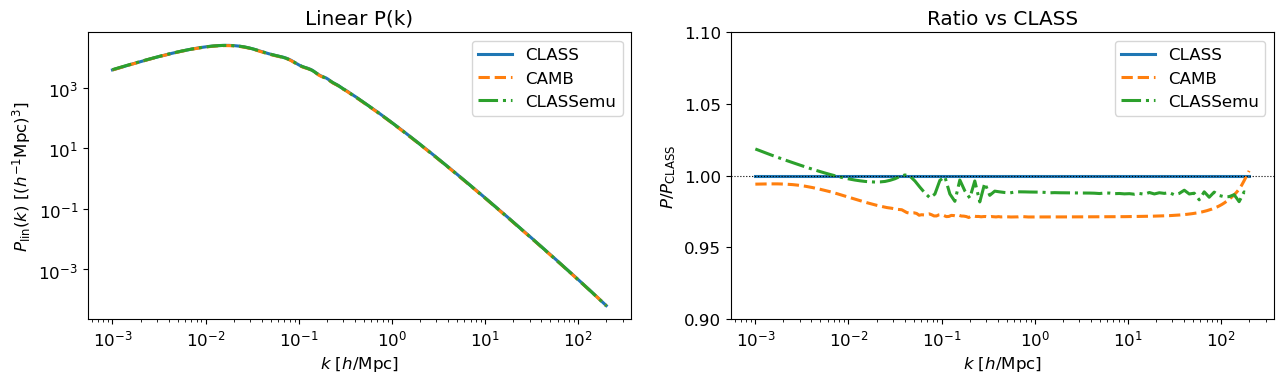

In [2]:
p_class    = deepcopy(par); p_class.file.ps    = 'CLASS'
p_camb     = deepcopy(par); p_camb.file.ps     = 'CAMB'
p_classemu = deepcopy(par); p_classemu.file.ps = 'CLASSemu'
# p_bacco  = deepcopy(par); p_bacco.file.ps    = 'BACCOemu'

p_class.cosmo.plin    = toolscosmo.get_Plin(p_class)
p_camb.cosmo.plin     = toolscosmo.get_Plin(p_camb)
p_classemu.cosmo.plin = toolscosmo.get_Plin(p_classemu)
# p_bacco.cosmo.plin  = toolscosmo.get_Plin(p_bacco)

solvers = [
    (p_class,    '-',  'CLASS'),
    (p_camb,     '--', 'CAMB'),
    (p_classemu, '-.', 'CLASSemu'),
    # (p_bacco,  ':',  'BACCOemu'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for p, ls, label in solvers:
    ax.loglog(p.cosmo.plin['k'], p.cosmo.plin['P'], ls=ls, label=label)
ax.set_xlabel(r'$k$ [$h$/Mpc]'); ax.set_ylabel(r'$P_{\rm lin}(k)$ [($h^{-1}$Mpc)$^3$]')
ax.set_title('Linear P(k)'); ax.legend()

# Ratio vs CLASS
from scipy.interpolate import splrep, splev
ref_k, ref_P = p_class.cosmo.plin['k'], p_class.cosmo.plin['P']
ref_interp = lambda k: 10**splev(np.log10(k), splrep(np.log10(ref_k), np.log10(ref_P)))

ax = axes[1]
for p, ls, label in solvers:
    k, P = p.cosmo.plin['k'], p.cosmo.plin['P']
    ax.semilogx(k, P / ref_interp(k), ls=ls, label=label)
ax.axhline(1, color='k', lw=0.8, ls=':')
ax.set_ylim(0.9, 1.1)
ax.set_xlabel(r'$k$ [$h$/Mpc]'); ax.set_ylabel(r'$P / P_{\rm CLASS}$')
ax.set_title('Ratio vs CLASS'); ax.legend()

plt.tight_layout(); plt.show()


## 2. Non-linear Matter Power Spectrum

Uses **HMcode-2020** ([Mead et al. 2021](https://arxiv.org/abs/2009.01858)), which wraps CAMB.  
The boost factor $B(k,z) = P_{\rm nl}(k,z) / P_{\rm lin}(k,z)$ shows the pure non-linear enhancement.

We also test the effect of **AGN feedback** via the temperature parameter $T_{\rm AGN}$.

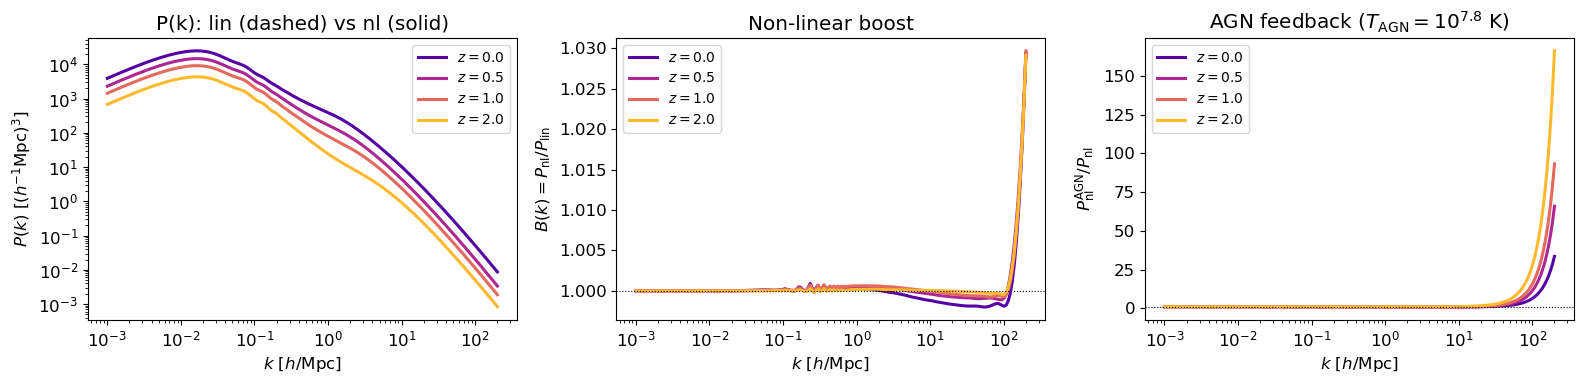

In [3]:
import hmcode

redshifts = [0.0, 0.5, 1.0, 2.0]
k = np.logspace(-3, np.log10(par.code.kmax), par.code.Nk)

res = camb_results(par, zs=redshifts)
plin_interp = res.get_matter_power_interpolator()

# hmcode requires redshifts in decreasing order; reverse output so index matches redshifts
zs_dec = redshifts[::-1]
Pk_nl      = hmcode.power(k, zs_dec, res)[::-1]           # no AGN feedback
Pk_nl_agn  = hmcode.power(k, zs_dec, res, T_AGN=10**7.8)[::-1]  # AGN feedback
Pk_lin_arr = np.array([plin_interp.P(z, k, grid=False) for z in redshifts])

boost     = Pk_nl     / Pk_lin_arr
boost_agn = Pk_nl_agn / Pk_lin_arr

colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(redshifts)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- P_nl absolute ---
ax = axes[0]
for iz, (z, c) in enumerate(zip(redshifts, colors)):
    ax.loglog(k, Pk_lin_arr[iz], color=c, ls='--', lw=1.5, alpha=0.6)
    ax.loglog(k, Pk_nl[iz],      color=c, ls='-',  label=f'$z={z}$')
ax.set_xlabel(r'$k$ [$h$/Mpc]'); ax.set_ylabel(r'$P(k)$ [($h^{-1}$Mpc)$^3$]')
ax.set_title('P(k): lin (dashed) vs nl (solid)'); ax.legend(fontsize=10)

# --- Boost B(k) = P_nl/P_lin ---
ax = axes[1]
for iz, (z, c) in enumerate(zip(redshifts, colors)):
    ax.semilogx(k, boost[iz], color=c, label=f'$z={z}$')
ax.axhline(1, color='k', lw=0.8, ls=':')
ax.set_xlabel(r'$k$ [$h$/Mpc]'); ax.set_ylabel(r'$B(k) = P_{\rm nl}/P_{\rm lin}$')
ax.set_title('Non-linear boost'); ax.legend(fontsize=10)

# --- AGN feedback: ratio P_nl(AGN)/P_nl ---
ax = axes[2]
for iz, (z, c) in enumerate(zip(redshifts, colors)):
    ax.semilogx(k, Pk_nl_agn[iz] / Pk_nl[iz], color=c, label=f'$z={z}$')
ax.axhline(1, color='k', lw=0.8, ls=':')
ax.set_xlabel(r'$k$ [$h$/Mpc]'); ax.set_ylabel(r'$P_{\rm nl}^{\rm AGN} / P_{\rm nl}$')
ax.set_title(r'AGN feedback ($T_{\rm AGN}=10^{7.8}$ K)'); ax.legend(fontsize=10)

plt.tight_layout(); plt.show()

## 3. Cosmological Parameter Dependence

Vary one parameter at a time around the fiducial cosmology.  
All spectra use CAMB (linear) + HMcode-2020 (non-linear) at $z=0$.

Parameters explored: $\Omega_m$, $A_s$ (amplitude / $\sigma_8$), $n_s$, $w_0$ (CPL dark energy).

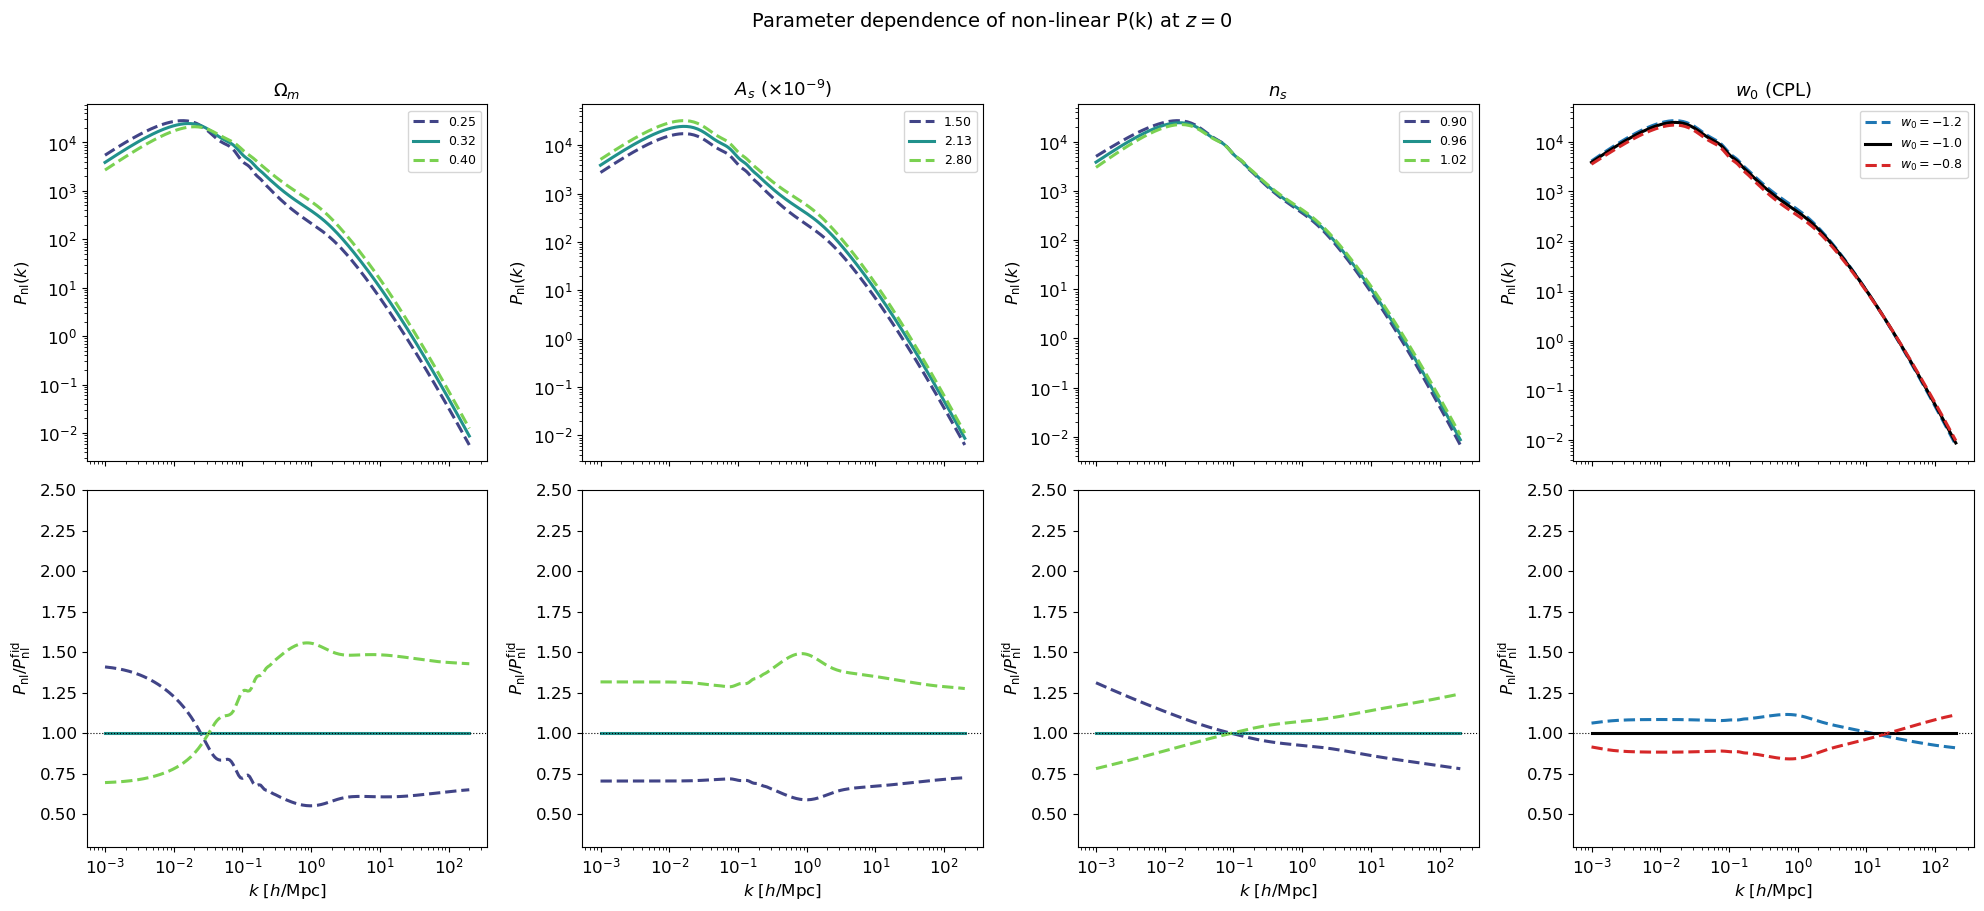

In [4]:
z0 = [0.0]

def pnl_for_par(p):
    """Return (k, P_lin, P_nl) at z=0 for a given toolscosmo par."""
    res   = camb_results(p, zs=z0)
    Pk_nl = hmcode.power(k, z0, res)[0]
    Pk_l  = res.get_matter_power_interpolator().P(0.0, k, grid=False)
    return Pk_l, Pk_nl

fid_lin, fid_nl = pnl_for_par(par)

# Parameter variations
variations = {
    r'$\Omega_m$': [
        ('Om', v, f'{v:.2f}') for v in [0.25, 0.315, 0.40]
    ],
    r'$A_s\ (\times 10^{-9})$': [
        ('As', v, f'{v*1e9:.2f}') for v in [1.5e-9, 2.126e-9, 2.8e-9]
    ],
    r'$n_s$': [
        ('ns', v, f'{v:.2f}') for v in [0.90, 0.963, 1.02]
    ],
    r'$w_0$ (CPL)': None,   # handled separately below
}

w0_vals = [(-1.2, 'C0'), (-1.0, 'k'), (-0.8, 'C3')]

fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharex=True)
cmap = plt.cm.viridis

for col, (plabel, var_list) in enumerate(variations.items()):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    if plabel == r'$w_0$ (CPL)':
        for w0val, color in w0_vals:
            p = deepcopy(par)
            p.DE = toolscosmo.param.de_par('CPL')
            p.DE.w0 = w0val; p.DE.wa = 0.0
            plin_v, pnl_v = pnl_for_par(p)
            ls = '-' if w0val == -1.0 else '--'
            ax_top.loglog(k, pnl_v,            color=color, ls=ls, label=f'$w_0={w0val}$')
            ax_bot.semilogx(k, pnl_v / fid_nl, color=color, ls=ls)
    else:
        colors_v = cmap(np.linspace(0.2, 0.8, len(var_list)))
        for (attr, val, vlabel), color in zip(var_list, colors_v):
            p = deepcopy(par)
            setattr(p.cosmo, attr, val)
            plin_v, pnl_v = pnl_for_par(p)
            ls = '-' if val == getattr(par.cosmo, attr) else '--'
            ax_top.loglog(k, pnl_v,            color=color, ls=ls, label=vlabel)
            ax_bot.semilogx(k, pnl_v / fid_nl, color=color, ls=ls)

    ax_top.set_title(plabel, fontsize=13)
    ax_top.set_ylabel(r'$P_{\rm nl}(k)$')
    ax_top.legend(fontsize=9)

    ax_bot.axhline(1, color='k', lw=0.8, ls=':')
    ax_bot.set_xlabel(r'$k$ [$h$/Mpc]')
    ax_bot.set_ylabel(r'$P_{\rm nl} / P_{\rm nl}^{\rm fid}$')
    ax_bot.set_ylim(0.3, 2.5)

plt.suptitle('Parameter dependence of non-linear P(k) at $z=0$', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()
